
# 1 Objective

You have historical monthly data of all milk products sold in the channel of price club stores at the national level.

You are supposed to be a data engineer and analyst in one of the 3 big manufacturers of milk products sold in this channel.

The objectives of your analysis are the following:

1. Provide understanding of the milk category **by manufacturer (fab)** in terms of a) **market share** composition by year, and b) **sales and price performance** over time. Identify the top fabs that make 80% of the market share for the last 12 months. Show relevant descriptive statistics according to your analysis and assumptions.

2. Provide initial correlation analysis to understand important relationship within the data. You have to justify how and why you did this correlation analysis. Explain your results

For 1) and 2) Present your analysis in tables and selected graphs to provide a **good understanding of the data.**

3. Design and run regression model(s) to estimate **price sensitivity (direct price elasticity)** for the top product of your manufacturer (fab#). Identify the top product as the product that sold the most for the last 12 months. For this model, only consider the price change as explanatory variable (do not include other factors such as seasonality or tren).

You have to present the regression output for the model and provide a **clear interpretation** for the regression output: parameter estimates (beta coefficients), t-Statistics, pvalues, 95% confidence intervals, and R-square.

4. Propose how you could **improve your model design to incorporate the following factors: cross-price elasticity with other products, seasonality and growth trend.** Here you have to explain your model design, not run the model.

5. For your model (of the top product), add variables to include the effects of seasonality and growing volume trend.

**Run the model, show the regression output and interpret the outputs**

In addition, respond to the following questions:

**Did the estimates of direct price elasticity change compared with the previous model?**
**What happened with the statistical significance of the price elasticity? Why do you think the estimates change, and which estimate is the best? Explain clearly with your own words.**

6. Propose how you could forecast price and sales of the top product for the next 24 months. Which types of models you can use to do this. You have to do your own research. Consider not only regression models, but any type of machine learning/ AI models.

# 2 PART 1 - Data wrangling and data understanding

You have to download (from Canvas) the following files:

1. DATOS_VENTAS.xlsx: historical monthly data for all products sold for the last 3-4 years

You have to:

1. Do a correct data wrangling/cleanning to prepare the data for descriptive statistics and modelling:

2. You have to check for null values, possible duplicate records (1 same product with 2 product ID, or 1 product ID with 2 different product names),

3. Then you have to do the right data collapsing, possible reshaping, and variable transformations, and come up with the right data structure for analysis. Remember dataset structure types (long-format, wide-format).

4. Do the corresponding data analysis to respond to the objective 1)

5. Run and interpret the regression model for your fab

# 3 PART 2 - Data modelling

You have to design, run models to respond to the objective and questions stated in 3), 4) and 5)

Go to Canvas and check DEADLINES for each part


In [52]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

## Cargar los datos del excel

In [53]:
df = pd.read_excel("./DATA_VENTAS.xlsx")
df

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


## Limpiar los datos tirando las columnas que no brindan información importante

1. Corte: Mismo valor en todas las instancias. 
1. Producto: Calculado mediante la fábrica y ID del producto
1. FechaM: Calculados mediante la fecha desglozada: año, semana mes -> Consideré que es mejor tener los valores particulares e independientes
1. Unidades en Paquete: Todos los productos cuentan con paquetes de 12

In [54]:
# Drop unimportant columns
df_clean = df.drop(columns=["CORTE", "PRODUCTO", "UNIDADES_EN_PAQUETE"])
df_clean

,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE
0,FAB1,1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438
1,FAB1,1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484
2,FAB1,1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420
3,FAB1,1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853
4,FAB1,1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522
...,...,...,...,...,...,...,...,...,...,...,...,...
3291,FAB3,1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978
3292,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344
3293,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188
3294,FAB3,1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654


## Limpiar dataset

Eliminar datos repetidos y nulos, productos que no se vendieron / no tengan ventas en litros o valor de venta son productos que no aportarán información al modelo.

Debido a las agrupaciones semanales lo ideal es calcular el promedio de precio unitario por litromediante la venta y litros vendidos.
Se considera repetidos si se tiene el mismo ID en la misma semaan y año, solución: Acumular las ventas, litros, paquetes y el promedio en precio unitario por litro y por paquete.

Esto fue ya que las ventas se acumulan, y los datos repetidos son por un cambio en el precio, el cual no hace sentido acumular.

In [55]:
# Group duplicate rows together for visual comparison
df_clean = df_clean[
    (df_clean["LITROS"] > 0) & (df_clean["VENTA_VALOR"] >= 0)
].copy()
duplicates = df_clean[df_clean.duplicated(subset=["ID", "AÑO1", "SEMANA"], keep=False)]
display(duplicates)

df_merged = df_clean.groupby(["ID", "AÑO1", "SEMANA"], as_index=False).agg({
	"FABRICANTE": "first",
 	"MES": "first",
 	"FECHAM": "first",
  "VENTA_VALOR": "sum",
  "LITROS": "sum",
  "PAQUETES": "sum",
})

cols = ["FABRICANTE"] + [col for col in df_merged.columns if col != "FABRICANTE"]
df_merged = df_merged[cols]

df_merged["PRECIO_UNITARIO_LITRO"] = df_merged["VENTA_VALOR"] / df_merged["LITROS"]
df_merged["PRECIO_UNITARIO_PAQUETE"] = df_merged["PRECIO_UNITARIO_LITRO"] * 12

print("Limpio:")
display(df_merged)

,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE
1629,FAB2,Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,211303.67,9336,22.633212,778,271.598548
1630,FAB2,Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,8397.00,396,21.204545,33,254.454545
1631,FAB2,Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,210346.78,10116,20.793474,843,249.521684
1632,FAB2,Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,80793.00,3924,20.589450,327,247.073394
1633,FAB2,Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,40552.91,1884,21.524899,157,258.298790
...,...,...,...,...,...,...,...,...,...,...,...,...
3291,FAB3,1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978
3292,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344
3293,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188
3294,FAB3,1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654


Limpio:


,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB2,100 70+30,2022,1,1,2022-01-01,271.00,12,1,22.583333,271.000000
1,FAB2,100 Low C Arb,2023,44,11,2023-11-01,24431.00,1092,91,22.372711,268.472527
2,FAB2,100 Low C Arb,2023,45,11,2023-11-01,83922.97,3744,312,22.415323,268.983878
3,FAB2,100 Low C Arb,2023,46,11,2023-11-01,77492.88,3456,288,22.422708,269.072500
4,FAB2,100 Low C Arb,2023,47,11,2023-11-01,131805.01,5904,492,22.324697,267.896362
...,...,...,...,...,...,...,...,...,...,...,...
3011,FAB5,Mm Leche Deslac Ligh,2025,27,7,2025-07-01,629750.74,33060,2755,19.048722,228.584661
3012,FAB5,Mm Leche Deslac Ligh,2025,28,7,2025-07-01,536578.27,28188,2349,19.035699,228.428382
3013,FAB5,Mm Leche Deslac Ligh,2025,29,7,2025-07-01,548231.53,28548,2379,19.203851,230.446208
3014,FAB5,Mm Leche Deslac Ligh,2025,30,7,2025-07-01,548597.09,28692,2391,19.120211,229.442530


In [56]:
df_merged_monthly = df_merged.groupby(["ID", "FECHAM"], as_index=False).agg({
	"FABRICANTE": "first",
 	"AÑO1": "first",
 	"MES": "first",
  "VENTA_VALOR": "sum",
  "LITROS": "sum",
  "PAQUETES": "sum",
})
cols = ["FABRICANTE"] + [col for col in df_merged_monthly.columns if col != "FABRICANTE"]
df_merged_monthly = df_merged_monthly[cols]

df_merged_monthly["PRECIO_UNITARIO_LITRO"] = df_merged_monthly["VENTA_VALOR"] / df_merged_monthly["LITROS"]
df_merged_monthly["PRECIO_UNITARIO_PAQUETE"] = df_merged_monthly["PRECIO_UNITARIO_LITRO"] * 12

print("Limpio:")
display(df_merged_monthly)

Limpio:


,FABRICANTE,ID,FECHAM,AÑO1,MES,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB2,100 70+30,2022-01-01,2022,1,271.00,12,1,22.583333,271.000000
1,FAB2,100 Low C Arb,2023-11-01,2023,11,402512.89,17988,1499,22.376745,268.520941
2,FAB2,100 Low C Arb,2023-12-01,2023,12,623084.68,29664,2472,21.004742,252.056909
3,FAB2,100 Low C Arb,2024-01-01,2024,1,679620.91,30300,2525,22.429733,269.156796
4,FAB2,100 Low C Arb,2024-02-01,2024,2,845147.81,38076,3173,22.196339,266.356070
...,...,...,...,...,...,...,...,...,...,...
704,FAB5,Mm 12/1L Leche Ente Members Mark,2025-06-01,2025,6,6780388.34,334920,27910,20.244800,242.937597
705,FAB5,Mm 12/1L Leche Ente Members Mark,2025-07-01,2025,7,9206183.92,476208,39684,19.332275,231.987298
706,FAB5,Mm Leche Deslac Ligh,2025-05-01,2025,5,1264602.61,64824,5402,19.508247,234.098965
707,FAB5,Mm Leche Deslac Ligh,2025-06-01,2025,6,1880243.64,93720,7810,20.062352,240.748225


In [57]:
# Auditoría de conservación: el colapso debe preservar ventas, litros y paquetes.
raw_totals = df_clean[["VENTA_VALOR", "LITROS", "PAQUETES"]].sum()
weekly_totals = df_merged[["VENTA_VALOR", "LITROS", "PAQUETES"]].sum()
monthly_totals = df_merged_monthly[["VENTA_VALOR", "LITROS", "PAQUETES"]].sum()
conservation_check = pd.DataFrame({
    "original_filtrado": raw_totals,
    "semanal": weekly_totals,
    "mensual": monthly_totals,
    "diferencia_original_mensual": raw_totals - monthly_totals,
})
display(conservation_check)

,original_filtrado,semanal,mensual,diferencia_original_mensual
VENTA_VALOR,2.294514e+09,2.294514e+09,2.294514e+09,4.768372e-07
LITROS,1.136100e+08,1.136100e+08,1.136100e+08,0.000000e+00
PAQUETES,9.466138e+06,9.466138e+06,9.466138e+06,0.000000e+00


In [58]:
def see_nan_values(df):
	df.info()
	nan_values = df.isnull().sum()
	print(nan_values / len(df) * 100)

	print(f"Lenght of dataset: {len(df)}")

In [59]:
see_nan_values(df_merged_monthly)

<class 'pandas.DataFrame'>
RangeIndex: 709 entries, 0 to 708
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   FABRICANTE               709 non-null    str           
 1   ID                       709 non-null    str           
 2   FECHAM                   709 non-null    datetime64[us]
 3   AÑO1                     709 non-null    int64         
 4   MES                      709 non-null    int64         
 5   VENTA_VALOR              709 non-null    float64       
 6   LITROS                   709 non-null    int64         
 7   PAQUETES                 709 non-null    int64         
 8   PRECIO_UNITARIO_LITRO    709 non-null    float64       
 9   PRECIO_UNITARIO_PAQUETE  709 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(2)
memory usage: 55.5 KB
FABRICANTE                 0.0
ID                         0.0
FECHAM                     0.0
AÑO

In [60]:
missing_prices = df_merged_monthly[
    df_merged_monthly["PRECIO_UNITARIO_LITRO"].isna() |
    df_merged_monthly["PRECIO_UNITARIO_PAQUETE"].isna()
]

display(missing_prices)

# df_clean = df_merged_monthly.dropna()
# see_nan_values(df_clean)

,FABRICANTE,ID,FECHAM,AÑO1,MES,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE


In [61]:
df = df_merged.sort_values(
	by=["FECHAM"]
).reset_index(drop=True)

display(df)

,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB2,100 70+30,2022,1,1,2022-01-01,271.00,12,1,22.583333,271.000000
1,FAB1,Leche Clasica Deslactosada Light 1 L,2022,1,1,2022-01-01,873312.15,45420,3785,19.227480,230.729762
2,FAB3,1L Desl Deslactosada,2022,1,1,2022-01-01,1223179.13,68280,5690,17.914164,214.969970
3,FAB3,1L Desl Deslactosada,2022,2,1,2022-01-01,875655.32,49092,4091,17.837027,214.044322
4,FAB3,1L Desl Deslactosada,2022,3,1,2022-01-01,659878.20,33132,2761,19.916643,238.999710
...,...,...,...,...,...,...,...,...,...,...,...
3011,FAB2,ENTERA 1.5LT 10PZ,2025,30,7,2025-07-01,353408.95,18390,1226,19.217452,230.609429
3012,FAB2,ENTERA 1.5LT 10PZ,2025,29,7,2025-07-01,175625.51,8400,560,20.907799,250.893586
3013,FAB2,ENTERA 1.5LT 10PZ,2025,28,7,2025-07-01,233470.96,11640,776,20.057643,240.691711
3014,FAB1,Leche Clasica Entera 1 L,2025,28,7,2025-07-01,1712427.87,80304,6692,21.324316,255.891792


## Observación 1
El porcentaje de ventas en el mercado de la fábrica 2 en que estoy haciendo el estudio es del 19.62%, cayendo en el tercer lugar. Durante los años se puede ver que se mantiene alrededor de 20 excepto en el 2025, cuando solo llego a representar el 11% del mercado, su peor año.

En los últimos 12 meses se peude ver que la fábrica 2 solo representa un ~13% del mercado, y el top 80% está repartido entre:
1. FAB1 - 36%
1. FAB3 - 28%
1. FAB5 - 22%

Estos representan poco más del 85%

,VENTA_VALOR,MARKET_SHARE
FABRICANTE,,
FAB1,9.660966e+08,42.104630
FAB2,4.497637e+08,19.601696
FAB3,6.928695e+08,30.196786
FAB5,1.563710e+08,6.814993
FAB6,2.941328e+07,1.281896


VENTA_VALOR  MARKET_SHARE
FABRICANTE AÑO1                            
FAB1       2022  2.634132e+08     44.636707
           2023  2.835175e+08     46.429807
           2024  2.745553e+08     41.291330
           2025  1.446106e+08     33.722295
FAB2       2022  1.240779e+08     21.025637
           2023  1.382947e+08     22.647610
           2024  1.375519e+08     20.686910
           2025  4.983917e+07     11.622185
FAB3       2022  1.853947e+08     31.416076
           2023  1.766527e+08     28.929248
           2024  2.108231e+08     31.706426
           2025  1.199990e+08     27.983024
FAB5       2024  4.199187e+07      6.315304
           2025  1.143791e+08     26.672496
FAB6       2022  1.724103e+07      2.921580
           2023  1.217204e+07      1.993335
           2024  2.040000e+02      0.000031

Text(0.5, 1.0, 'Market Share overview')

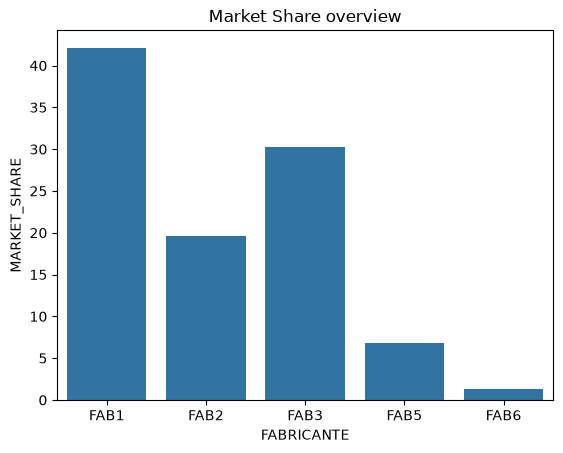

In [62]:
market_share = df_merged_monthly.groupby("FABRICANTE").agg({
	"VENTA_VALOR": "sum"
})
market_share_year = df_merged_monthly.groupby(["FABRICANTE", "AÑO1"]).agg({
	"VENTA_VALOR": "sum"
})

total = market_share["VENTA_VALOR"].sum()
total_anual = market_share_year.groupby("AÑO1")["VENTA_VALOR"].sum()

market_share["MARKET_SHARE"] = market_share["VENTA_VALOR"] / total * 100
market_share_year["MARKET_SHARE"] = market_share_year["VENTA_VALOR"] / total_anual * 100
display(market_share)
display(market_share_year)

sns.barplot(market_share, x="FABRICANTE", y="MARKET_SHARE")
plt.title("Market Share overview")

,VENTA_VALOR,SHARE
FABRICANTE,,
FAB1,2.553917e+08,35.932624
FAB2,9.488981e+07,13.350629
FAB3,2.040994e+08,28.715991
FAB5,1.563707e+08,22.000756


Text(0.5, 1.0, 'Market share in the last 12 months')

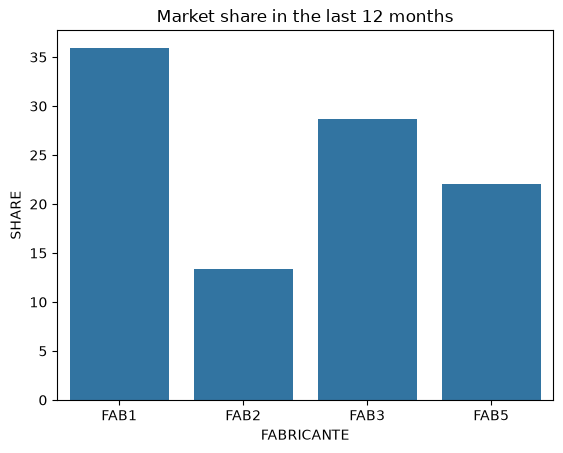

In [63]:
market_share_monthly = (
    df_merged_monthly.groupby(["FABRICANTE", "AÑO1", "MES"])["VENTA_VALOR"]
      .sum()
      .reset_index()
      .sort_values(["AÑO1", "MES"])
)

# Últimos 12 meses
last_12_months = market_share_monthly[
    ["AÑO1", "MES"]
].drop_duplicates().tail(12)

market_share_monthly = market_share_monthly.merge(
    last_12_months,
    on=["AÑO1", "MES"],
    how="inner"
)

market_share_monthly = market_share_monthly.groupby("FABRICANTE").agg({
	"VENTA_VALOR": "sum"
})

market_share_monthly["SHARE"] = market_share_monthly["VENTA_VALOR"] / market_share_monthly["VENTA_VALOR"].sum() * 100
display(market_share_monthly)

sns.barplot(market_share_monthly, x="FABRICANTE", y="SHARE")
plt.title("Market share in the last 12 months")


## Filtrar Por fábrica 2

Las ventas se mantienen constante, la venta oscila entre 28e5 y 40e5, en comparación el precio de la leche ha ido en aumento casi constante con un incremento del 2022 donde el precio se encontraba alrededor de 18 a actualmente donde subió hasta ~23

Mínimo litros: 12
Media litros: 111270.43478260869
Mediana litros: 87144.0
Máximo litros: 306444

Mínimo precio por litro: 12.283787037037039
Media precio por litro: 20.606077333703684
Mediana precio por litro: 19.677367047110238
Máximo precio por litro: 28.746252764612947


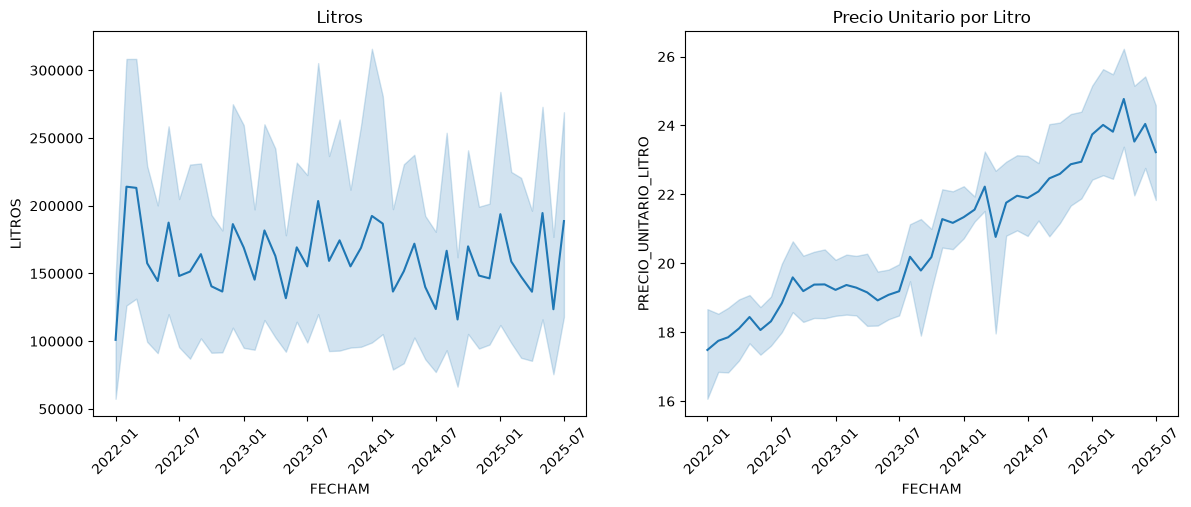

In [64]:
df_fab2 = df_merged_monthly[df_merged_monthly["FABRICANTE"] == "FAB2"]
df_fab2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(df_merged_monthly, x="FECHAM", y="LITROS", ax=axes[0])
axes[0].set_title("Litros")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(df_merged_monthly, x="FECHAM", y="PRECIO_UNITARIO_LITRO", ax=axes[1])
axes[1].set_title("Precio Unitario por Litro")
axes[1].tick_params(axis="x", rotation=45)

print(f"Mínimo litros: {df_fab2["LITROS"].min()}")
print(f"Media litros: {df_fab2["LITROS"].mean()}")
print(f"Mediana litros: {df_fab2["LITROS"].median()}")
print(f"Máximo litros: {df_fab2["LITROS"].max()}")
print(f"\nMínimo precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].min()}")
print(f"Media precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].mean()}")
print(f"Mediana precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].median()}")
print(f"Máximo precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].max()}")

## Correlación

Debido a que la muestra de datos de ventas de productos de la Fab2, decidí buscar si hay una correlación en ventas con los meses similar a como operan las ventas de ciertos productos.

En el heatmap se peude ver que hay una relación positiva media-fuerte entre los meses de enero a agosto, y entre septiembre a diciembre. Entre estos se puede ver que si hay varias ventas en los periodos de abril a agosto, entonces sus ventas aumentarán cadames, pero las ventas de invierno disminuirían. 

Puntos de interés, marzo parece ser independiente, ya que tiene una relación positiva con el resto del año a escepción de agosto. Hay una relación directa fuerte positiva entre marzo y noviembre con diciembre, y una negativa de junio con octubre y noviembre. Y enero es el mes más independiente, que sus relaciones son muy cercanas a 0, indicando que su relación con ellas es casi nula.

Con estos datos se podría planear las ventas del año, si durante el año se está teniendo una demanda baja, se podría creer que las ventas en la época de invierno aumentarán considerablemente, permitiendo prepararse para poder suplir la demanda. O de igual manera, si diciembre de un año terminó siendo baja, se podría determinar que al año siguiente la demanda de los primeros meses va a aumentar. 

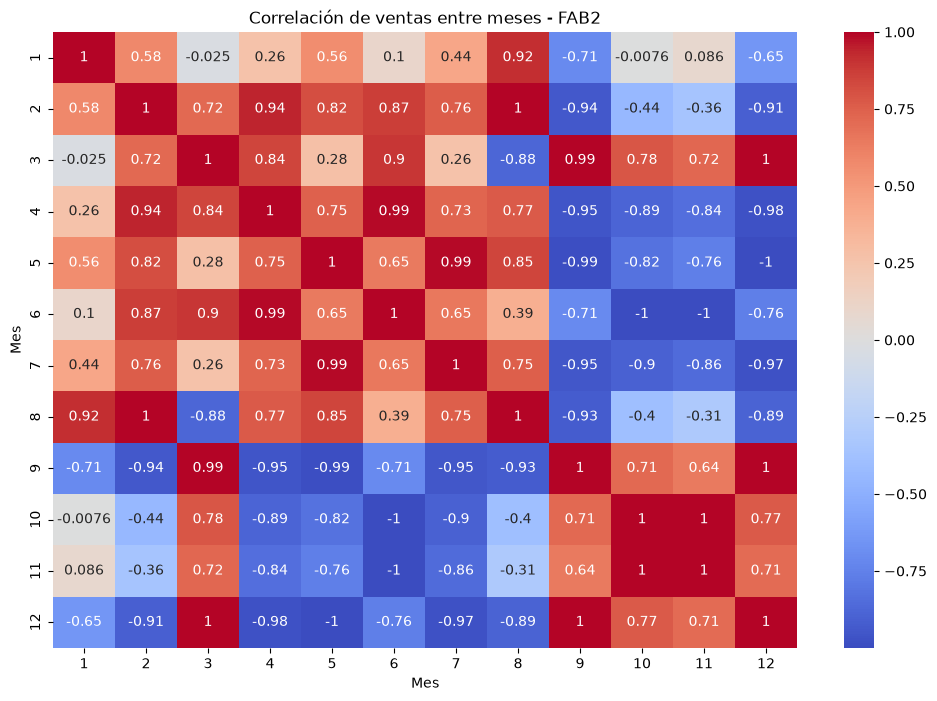

In [65]:
monthly_sales = (
    df_fab2
    .groupby(["AÑO1", "MES"])["VENTA_VALOR"]
    .sum()
    .unstack()
)

correlation_months = monthly_sales.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_months,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación de ventas entre meses - FAB2")
plt.xlabel("Mes")
plt.ylabel("Mes")

plt.show()

La correlación entre litros y precio es aproximadamente $-0.50$, lo que indica una asociación lineal negativa moderada en esta muestra de FAB2. No es una elasticidad: no permite afirmar que un aumento de 1% en precio cause una disminución de 0.5% en litros. Esa interpretación requiere una regresión log-log, como la estimada en la Parte 2.

Además, algunas correlaciones son mecánicas: $VENTA\_VALOR = PRECIO\_UNITARIO\_LITRO \times LITROS$ y el precio por paquete se deriva del precio por litro y del tamaño del paquete. Por eso no se deben presentar esas relaciones como evidencia económica independiente. La correlación entre meses también es débil como evidencia porque cada celda usa sólo 3 o 4 años de observaciones. Para inferir elasticidades se requieren modelos con controles de calendario, tendencia, estacionalidad y, si es posible, precios competitivos.

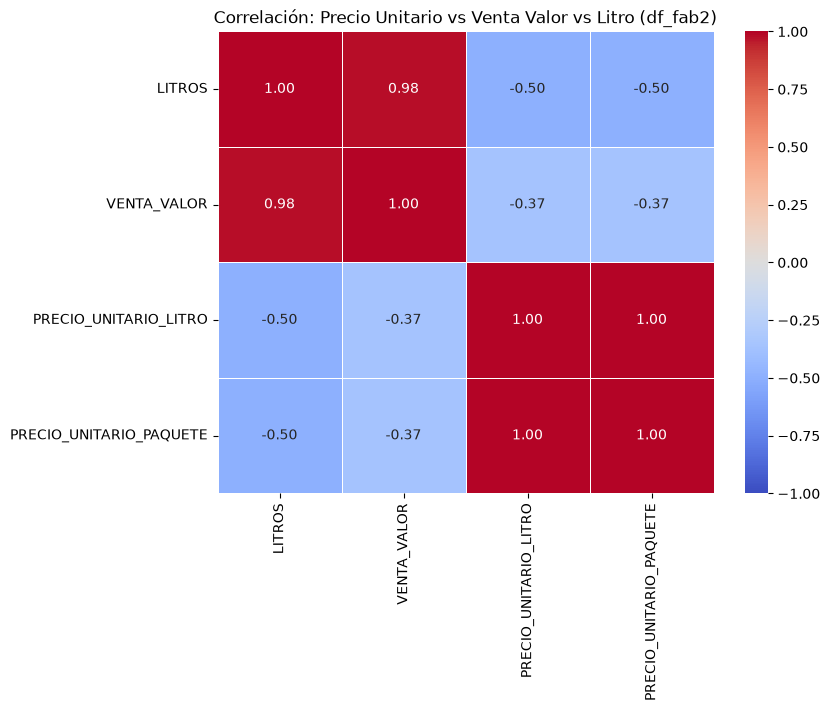

In [66]:
cols_interes = [
    "LITROS",
    "VENTA_VALOR",
    "PRECIO_UNITARIO_LITRO",
    "PRECIO_UNITARIO_PAQUETE",
]

corr_precio_valor = df_fab2[cols_interes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_precio_valor,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Correlación: Precio Unitario vs Venta Valor vs Litro (df_fab2)")
plt.show()

## Análisis de la información

Las ventas de FAB2 muestran variación entre productos y una caída reciente en varios SKU, mientras el precio promedio aumenta. Esta lectura es descriptiva: no atribuye causalidad al precio porque la tendencia, la estacionalidad, las promociones y la composición del portafolio también pueden mover el volumen.

VENTA_VALOR
ID                  FECHAM                 
  100  70+30        2022-01-01       271.00
 100 Low C Arb      2023-11-01    402512.89
                    2023-12-01    623084.68
                    2024-01-01    679620.91
                    2024-02-01    845147.81
...                                     ...
12/1L  100 Proteina 2025-03-01   2121049.63
                    2025-04-01   2183565.36
                    2025-05-01   2667274.07
                    2025-06-01   1678837.94
                    2025-07-01   2934530.31

[207 rows x 1 columns]

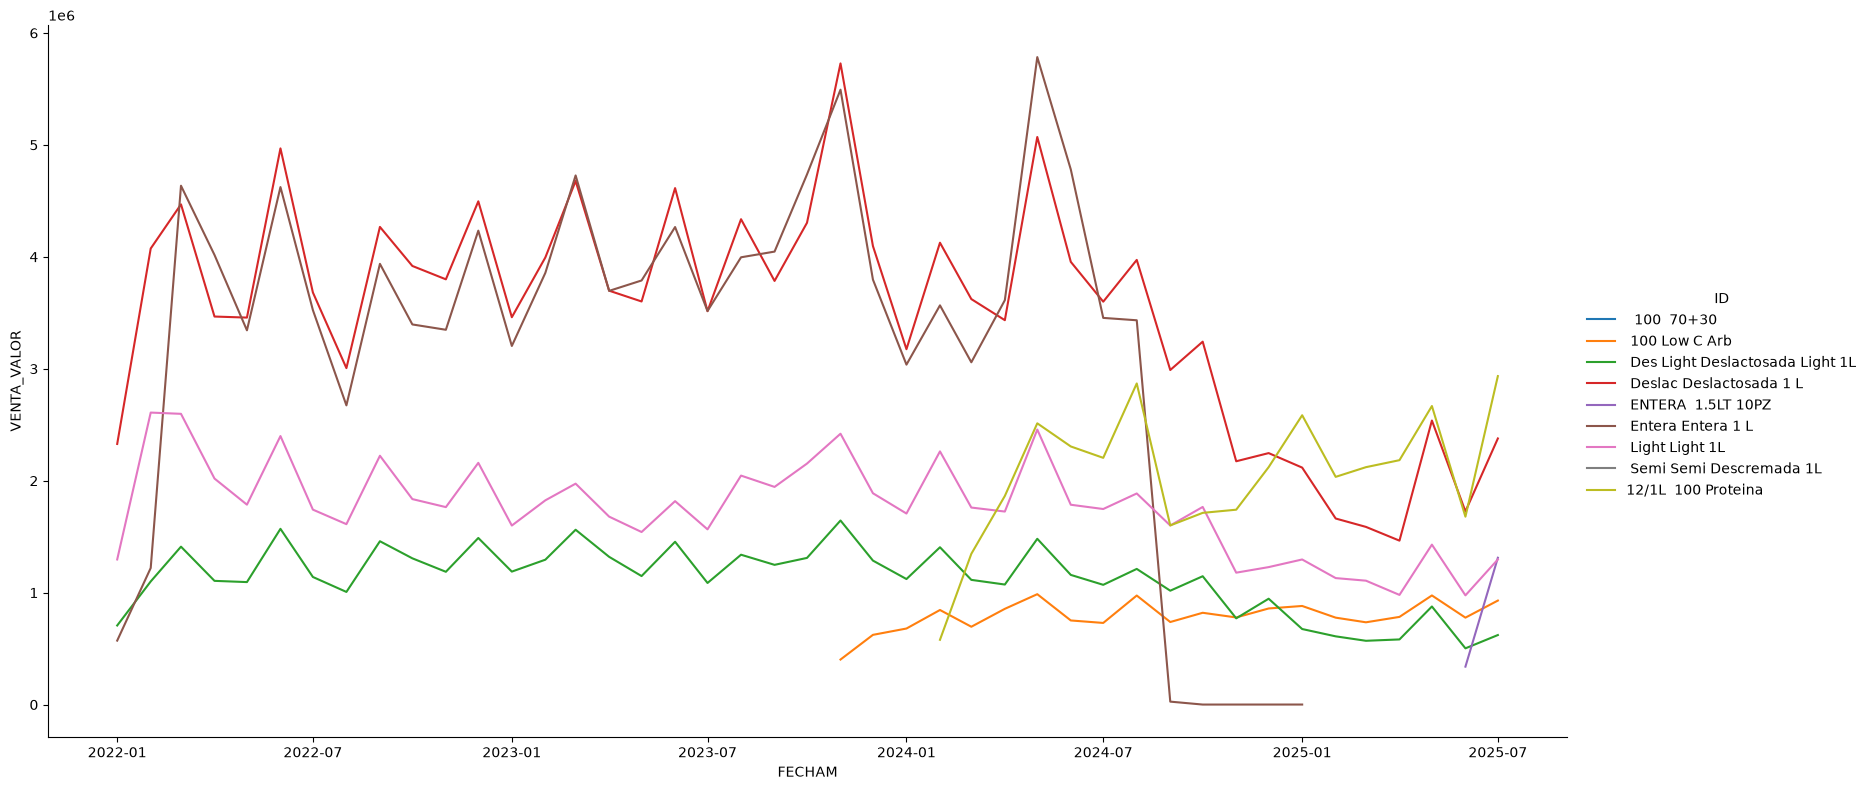

In [67]:
df_fab2_productos = df_fab2.groupby(["ID", "FECHAM"]).agg({
 	"VENTA_VALOR": "sum"
})

display(df_fab2_productos)

sns.relplot(
  data=df_fab2_productos,
  kind='line',
	x="FECHAM",
	y="VENTA_VALOR",
	hue="ID",
	height=8,
	aspect=2
  )

# Modelo exploratorio inicial: elasticidad con los últimos 12 meses

Este modelo de 12 observaciones es sólo una exploración inicial y no se utiliza para comparar el efecto de agregar controles. La comparación válida se presenta más adelante con el modelo simple y el extendido estimados sobre los mismos 43 meses.

La forma log-log es $\ln(Litros_t)=\beta_0+\beta_1\ln(Precio_t)+\epsilon_t$, donde $\beta_1$ se interpreta como elasticidad porcentual. El resultado exploratorio fue aproximadamente $\beta_1=-6.57$, con $R^2=0.708$, pero su intervalo de confianza es amplio por el tamaño muestral reducido.

Las limitaciones son importantes: la tendencia y la estacionalidad quedan en el residual; el precio unitario es $\sum Valor/\sum Litros$ y puede estar relacionado con promociones y decisiones de volumen; y $R^2$ mide la proporción de variación explicada dentro de la muestra, no la calidad garantizada de las predicciones futuras. Por eso el resultado de 12 meses no debe presentarse como evidencia causal ni compararse directamente con el modelo de 43 meses.

In [68]:
fecha_max = df_fab2["FECHAM"].max()
fecha_inicio = fecha_max - pd.DateOffset(months=12)

df_last12 = df_fab2[
    (df_fab2["FECHAM"] > fecha_inicio) &
    (df_fab2["FECHAM"] <= fecha_max)
].copy()

# Producto que más vendió
top_product_sales = (
    df_last12
    .groupby("ID")["VENTA_VALOR"]
    .sum()
    .sort_values(ascending=False)
)

top_id = top_product_sales.index[0]

# Producto que más vendió
top_liters = (
    df_last12
    .groupby("ID")["LITROS"]
    .sum()
    .sort_values(ascending=False)
)

top_id = top_product_sales.index[0]
top_liters_id = top_liters.index[0]

print("Producto que genero mayor ingreso:", top_id)
print("Valor de ventas:", top_product_sales.iloc[0])
print("Producto con mayor cantidad de litros vendidos:", top_liters_id)
print("Litros vendidos:", top_liters.iloc[0])

Producto que genero mayor ingreso:  Deslac Deslactosada 1 L
Valor de ventas: 28096797.87
Producto con mayor cantidad de litros vendidos:  Deslac Deslactosada 1 L
Litros vendidos: 1274808


In [69]:
df_top = df_last12[
    df_last12["ID"] == top_id
].copy()

df_monthly = (
    df_top
    .groupby(["AÑO1", "MES"])
    .agg({
        "LITROS": "sum",
        "PRECIO_UNITARIO_LITRO": "mean"
    })
    .reset_index()
)

df_model = df_monthly[
    (df_monthly["LITROS"] > 0) &
    (df_monthly["PRECIO_UNITARIO_LITRO"] > 0)
].copy()

df_model["log_sales"] = np.log(df_model["LITROS"])
df_model["log_price"] = np.log(df_model["PRECIO_UNITARIO_LITRO"])

X = sm.add_constant(df_model["log_price"])
y = df_model["log_sales"]

model = sm.OLS(y, X).fit()

print(model.summary())
r2_ajustada = model.rsquared_adj
print(f"R^2 Ajustada: {r2_ajustada}")

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     24.21
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           0.000605
Time:                        16:39:12   Log-Likelihood:                 3.7669
No. Observations:                  12   AIC:                            -3.534
Df Residuals:                      10   BIC:                            -2.564
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.9028      4.143      7.700      0.0

Utilizando el precio mínimo y máximo en que se han vendido sus produuctos, y la ecuación de regresión que se consiguió en el paso anterior creé la gráfica que demuestre como la cantidad de ventas disminuye deacuerdo al precio del producto.

En esta se puede ver como la Leche Deslactosada 1L (Variable con la que se hizo el modelo) y la entera siguen bastante fielmente, aunque con ruido, la tendencia que nos dió la fórmula; y las demás leches demuestran un comportamiento similar aunque con menos magnitud. Esto explica que la regresión final muestra la tendencia de venta, pero por la misma variabilidad de esta no se puede adaptar de una manera perfecta a esta. Explicando el motivo de la $R^2$ de 0.7, $ R^2 $ Ajustada: 0.6784, debido a que la diferencia entre la R^2 y R^2 ajustada podemos entender que no tenemos variables innecesarias y no tenemos un sobreajuste. 


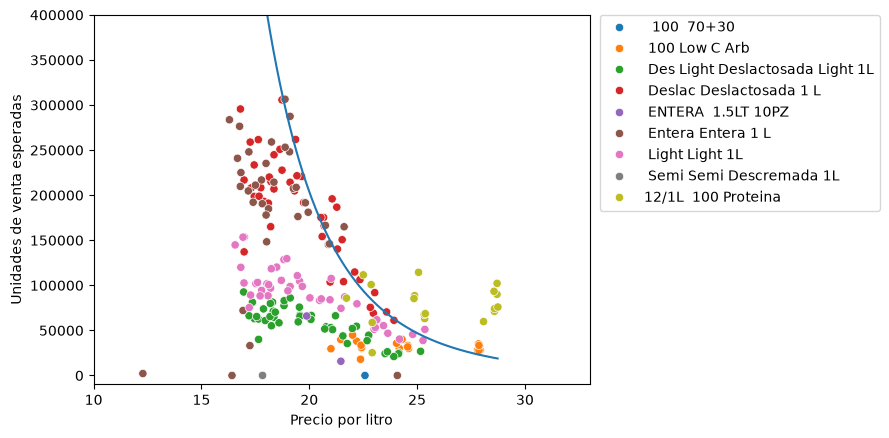

In [70]:
# Testing regression model
minimo, maximo = df_fab2["PRECIO_UNITARIO_LITRO"].min(), df_fab2["PRECIO_UNITARIO_LITRO"].max()
prices = np.arange(minimo, maximo, 0.05)

log_liters = 31.9028 + -6.5685 * np.log(prices)
liters = np.exp(log_liters)

sns.scatterplot(
	data=df_fab2,
	x="PRECIO_UNITARIO_LITRO",
 	y="LITROS",
  hue="ID"
)

sns.lineplot(x=prices, y=liters)

plt.ylim(top=400_000, bottom=-10_000)
plt.xlim(right=33, left=10)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.xlabel("Precio por litro")
plt.ylabel("Unidades de venta esperadas")
plt.show()

In [71]:
df_model["predicted_log_liters"] = model.predict(X)
df_model["error"] = np.abs(np.log(df_model["LITROS"]) - df_model["predicted_log_liters"])

display(df_model)

max_error = df_model["error"].max()
mean_error = df_model["error"].mean()
min_error = df_model["error"].min()

print("Max error", max_error)
print("Mean error", mean_error)
print("Min error", min_error)

,AÑO1,MES,LITROS,PRECIO_UNITARIO_LITRO,log_sales,log_price,predicted_log_liters,error
0,2024,8,186708,21.276613,12.137301,3.057608,11.818831,0.318470
1,2024,9,140280,21.307414,11.851396,3.059055,11.809329,0.042066
2,2024,10,150624,21.524905,11.922542,3.069211,11.742622,0.179920
3,2024,11,103680,20.966389,11.549065,3.042921,11.915309,0.366245
4,2024,12,104064,21.589975,11.552761,3.072229,11.722796,0.170034
5,2025,1,91908,23.036099,11.428543,3.137063,11.296936,0.131608
6,2025,2,70476,23.587248,11.163028,3.160706,11.141631,0.021396
7,2025,3,69108,22.970756,11.143426,3.134222,11.315594,0.172168
8,2025,4,61212,23.927739,11.022099,3.175038,11.047490,0.025392
9,2025,5,114792,22.106960,11.650877,3.095892,11.567362,0.083515


Max error 0.36624460145990945
Mean error 0.14274718713620219
Min error 0.02139601546770109


## Diseño del modelo extendido: elasticidad directa y cruzada

Para estimar la demanda del producto líder propongo el siguiente modelo log-log mensual:

$$
\ln(Q_t) = \beta_0 + \beta_1\ln(P_{propio,t}) + \sum_j \gamma_j\ln(P_{j,t}) + \sum_{m=2}^{12}\delta_m D_{m,t} + \theta t + u_t
$$

Aquí $Q_t$ son los litros vendidos, $P_{propio,t}$ es el precio del producto de FAB2 y $P_{j,t}$ son los precios de productos competidores. El coeficiente $\beta_1$ es la elasticidad directa: espero que sea negativo. Cada $\gamma_j$ es una elasticidad cruzada: espero un signo positivo si el producto $j$ es sustituto, porque un aumento de su precio puede desplazar volumen hacia mi producto; para un complemento esperaría un signo negativo.

La estacionalidad entraría mediante 11 dummies mensuales, con enero como categoría base, o mediante términos de Fourier si hubiera más años de historia. La tendencia $t$ es lineal sobre $\ln(Q_t)$, por lo que representa un crecimiento porcentual aproximadamente constante, equivalente a una trayectoria exponencial del volumen.

El principal riesgo es la multicolinealidad: en esta base los precios de los fabricantes tienen correlaciones aproximadas entre 0.8 y 0.98 por la inflación láctea común. Por eso los $\gamma_j$ pueden perder significancia aunque exista sustitución. Una alternativa más estable es reparametrizar el precio competitivo como precio relativo, por ejemplo $\ln(P_{propio,t}/P_{categoria,t})$, o seleccionar pocos rivales con una justificación económica.

## Modelo extendido con calendario, estacionalidad y tendencia

El modelo se estimó sobre los 43 meses completos disponibles y ahora incluye el logaritmo del número de semanas observadas en el mes, porque 15 meses tienen 5 semanas y 28 tienen 4. También incluye la tendencia lineal y 11 dummies mensuales, con enero como base:

$$
\ln(L_t) = \beta_0 + \beta_1\ln(P_t) + \beta_w\ln(N\_SEMANAS_t) + \theta TREND_t + \sum_{m=2}^{12}\delta_m D_{m,t} + u_t
$$

La estimación obtenida fue $\beta_1=-5.5199$, $\beta_w=1.1577$, $\theta=0.0184$ y $R^2=0.824$ ($R^2$ ajustada $=0.736$). La tendencia positiva representa un crecimiento mensual pequeño; el control de semanas corrige el volumen contable adicional de los meses de cinco semanas. El precio es significativo, mientras que la tendencia es marginal ($p=0.056$) y varias dummies mensuales no son significativas individualmente.

In [72]:
# Construir la serie mensual completa del producto líder usando la información semanal colapsada.
df_top_weekly = df_merged[df_merged["ID"] == top_id].copy()

df_monthly = (
    df_top_weekly.groupby("FECHAM")
    .agg(
        AÑO1=("AÑO1", "first"),
        MES=("MES", "first"),
        LITROS=("LITROS", "sum"),
        VENTA_VALOR=("VENTA_VALOR", "sum"),
        N_SEMANAS=("SEMANA", "nunique"),
    )
    .reset_index()
    .sort_values("FECHAM")
    .reset_index(drop=True)
)

# El precio mensual es ponderado: valor total dividido entre litros totales.
df_monthly["PRECIO_UNITARIO_LITRO"] = (
    df_monthly["VENTA_VALOR"] / df_monthly["LITROS"]
)
df_model = df_monthly[
    (df_monthly["LITROS"] > 0)
    & (df_monthly["PRECIO_UNITARIO_LITRO"] > 0)
    & (df_monthly["N_SEMANAS"] > 0)
].copy()

# Ambas especificaciones usan exactamente los mismos meses para hacer una comparación válida.
df_model["log_sales"] = np.log(df_model["LITROS"])
df_model["log_price"] = np.log(df_model["PRECIO_UNITARIO_LITRO"])
df_model["log_weeks"] = np.log(df_model["N_SEMANAS"])
df_model["TREND"] = np.arange(1, len(df_model) + 1)

# Modelo simple comparable: precio solamente, pero sobre toda la historia disponible.
X_simple = sm.add_constant(df_model[["log_price"]])
model_simple_43 = sm.OLS(df_model["log_sales"], X_simple).fit()

# Modelo extendido: precio, calendario, tendencia y 11 dummies mensuales (enero es la base).
month_dummies = pd.get_dummies(
    df_model["MES"], prefix="MES", drop_first=True, dtype=float
)
X_extended = pd.concat(
    [df_model[["log_price", "log_weeks", "TREND"]], month_dummies],
    axis=1,
)
X_extended = sm.add_constant(X_extended)
model_extended = sm.OLS(df_model["log_sales"], X_extended).fit()

print(f"Observaciones comparables: {len(df_model)}")
print("Distribución de semanas:")
print(df_model["N_SEMANAS"].value_counts().sort_index())
print("\nModelo simple sobre la misma muestra de 43 meses:")
print(model_simple_43.summary())
print("\nModelo extendido con semanas, tendencia y estacionalidad:")
print(model_extended.summary())
print(
    f"\nElasticidad simple: {model_simple_43.params['log_price']:.4f}"
    f" | Elasticidad extendida: {model_extended.params['log_price']:.4f}"
)

Observaciones comparables: 43
Distribución de semanas:
N_SEMANAS
4    28
5    15
Name: count, dtype: int64

Modelo simple sobre la misma muestra de 43 meses:
                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     77.24
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           5.63e-11
Time:                        16:39:13   Log-Likelihood:                0.92591
No. Observations:                  43   AIC:                             2.148
Df Residuals:                      41   BIC:                             5.671
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|

## Comparación e interpretación de los modelos

Para responder si cambió la elasticidad, ambos modelos deben usar los mismos 43 meses. El modelo simple comparable, con solo $\ln(P)$, estima una elasticidad de $-3.2332$. Al agregar semanas, tendencia y estacionalidad, el coeficiente de precio es $-5.5199$. Por tanto, la elasticidad **bajó en sentido numérico** y aumentó en magnitud absoluta: pasó de $-3.23$ a $-5.52$. No debe compararse con el $-6.57$ del análisis exploratorio de 12 observaciones, porque aquel modelo usa una muestra distinta.

La interpretación correcta del modelo extendido es: manteniendo constantes el calendario, la tendencia y el mes, un aumento de 1% en el precio se asocia con una disminución aproximada de 5.52% en los litros vendidos. El coeficiente de semanas, $1.1577$, confirma que un mes con más semanas tiene más volumen contable. La tendencia es positiva ($0.0184$ por mes), pero su evidencia individual es marginal al 5%. El precio sí es estadísticamente significativo ($t=-4.862$, $p<0.001$; IC 95% aproximadamente $[-7.85,-3.19]$).

El modelo extendido explica el 82.4% de la variación muestral de $\ln(LITROS)$; esto no garantiza una predicción futura. El Durbin-Watson de 0.605 sugiere autocorrelación positiva importante, así que aún queda estructura temporal sin explicar y los errores estándar OLS deben interpretarse con cautela. También persisten riesgos de variable omitida y endogeneidad: el precio unitario se construye como valor dividido entre litros y puede reflejar promociones o decisiones simultáneas de volumen.

In [73]:
df_model["predicted_log_liters"] = model.predict(X)
df_model["error"] = np.abs(np.log(df_model["LITROS"]) - df_model["predicted_log_liters"])

display(df_model)

max_error = df_model["error"].max()
mean_error = df_model["error"].mean()
min_error = df_model["error"].min()

print("Max error", max_error)
print("Mean error", mean_error)
print("Min error", min_error)

,FECHAM,AÑO1,MES,LITROS,VENTA_VALOR,N_SEMANAS,PRECIO_UNITARIO_LITRO,log_sales,log_price,log_weeks,TREND,predicted_log_liters,error
0,2022-01-01,2022,1,137136,2328456.02,4,16.979174,11.828728,2.831988,1.386294,1,11.818831,0.009897
1,2022-02-01,2022,2,233556,4074388.11,4,17.445016,12.361177,2.859054,1.386294,2,11.809329,0.551848
2,2022-03-01,2022,3,258912,4468837.57,5,17.260064,12.464244,2.848395,1.609438,3,11.742622,0.721621
3,2022-04-01,2022,4,198684,3466617.89,4,17.447897,12.199471,2.859219,1.386294,4,11.915309,0.284162
4,2022-05-01,2022,5,193200,3457344.17,4,17.895156,12.171481,2.884530,1.386294,5,11.722796,0.448686
5,2022-06-01,2022,6,295620,4968837.71,5,16.808192,12.596830,2.821866,1.609438,6,11.296936,1.299894
6,2022-07-01,2022,7,216864,3681598.32,4,16.976531,12.287026,2.831832,1.386294,7,11.141631,1.145394
7,2022-08-01,2022,8,165060,3005916.62,4,18.211054,12.014064,2.902029,1.386294,8,11.315594,0.698470
8,2022-09-01,2022,9,227760,4267421.69,5,18.736484,12.336048,2.930473,1.609438,9,11.047490,1.288557
9,2022-10-01,2022,10,215052,3918524.95,4,18.221290,12.278635,2.902591,1.386294,10,11.567362,0.711273


Max error 1.2998944055705142
Mean error 0.7464342014426452
Min error 0.009897021959679009


## Pronóstico de los próximos 24 meses

Para pronosticar ventas primero debo pronosticar el precio, porque el precio es una variable explicativa del volumen. Una estrategia operativa sería:

1. Pronosticar el precio mensual con un modelo de series de tiempo como ARIMA o SARIMA, incluyendo estacionalidad mensual e intervalos de predicción.
2. Usar cada trayectoria de precio pronosticada en el modelo de demanda extendido, con las dummies mensuales, la tendencia y el calendario esperado.
3. Generar pronósticos puntuales e intervalos para litros y valor de ventas; para el valor, multiplicar litros pronosticados por precio pronosticado.

SARIMA es una opción apropiada como línea base para una serie mensual con autocorrelación y estacionalidad, porque incorpora rezagos, diferencias y un periodo estacional de 12 meses. Como alternativa de machine learning, se puede crear una matriz con variables rezagadas de precio y litros, medias móviles, mes, tendencia y precios relativos de competidores, y entrenar un modelo como Random Forest, Gradient Boosting o XGBoost. La validación debe ser temporal, con ventanas móviles, y no una partición aleatoria.

Monte Carlo no es por sí mismo un modelo de pronóstico: es una técnica para propagar la incertidumbre. Puede aplicarse después de ajustar SARIMA o la regresión, simulando trayectorias de precio, residuos y escenarios de demanda para obtener percentiles y probabilidades de cumplimiento de metas.

Campagna, G. (2026, agosto 5). Método de Monte Carlo: ué es, ejemplos y aplicacioes. pipedrive. [Método de Monte Carlo: ué es, ejemplos y aplicacioes](https://www.pipedrive.com/es/blog/metodo-monte-carlo)